In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q transformers torch scikit-learn joblib

In [3]:
import torch
import torch.nn.functional as F
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [4]:
MODEL_PATH = "/content/drive/MyDrive/AI_Neurological_Project/models/neurology_model_v1"

In [5]:
label_encoder = joblib.load(
    "/content/drive/MyDrive/AI_Neurological_Project/label_encoder.pkl"
)

print("Loaded", len(label_encoder.classes_), "diseases")

Loaded 30 diseases


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

print("Tokenizer Loaded Successfully!")

Tokenizer Loaded Successfully!


In [7]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

model.eval()

print("Using:", device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Using: cuda


In [8]:
# Load test dataset
test_df = pd.read_csv("/content/drive/MyDrive/AI_Neurological_Project/test.csv")

# Generate predictions
predictions = []

for text in test_df["text"]:

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1).item()
    predictions.append(pred)

# Ground truth and predictions
y_true = test_df["label_encoded"].values
y_pred = np.array(predictions)

# Classification report DataFrame
report = classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

print("Ready to generate graphs!")

Ready to generate graphs!


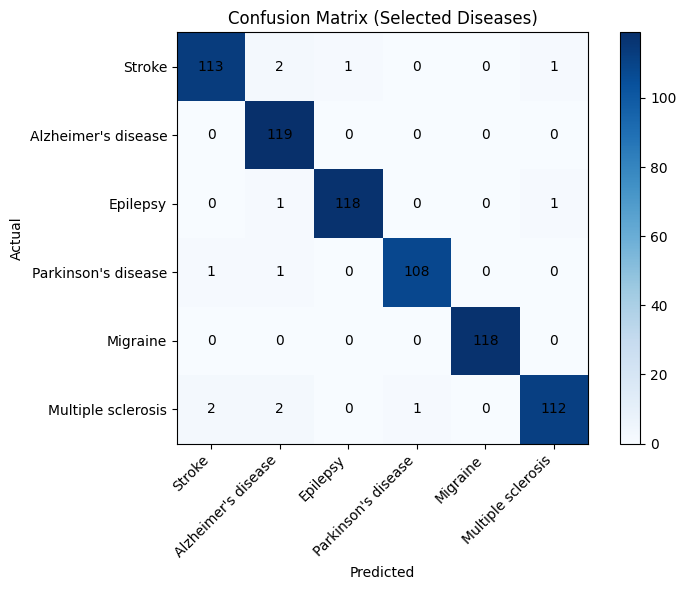

In [9]:
#Confusion Matrix of the six diseases

selected_diseases = [
    "Stroke",
    "Alzheimer's disease",
    "Epilepsy",
    "Parkinson's disease",
    "Migraine",
    "Multiple sclerosis"
]

selected_indices = [
    np.where(label_encoder.classes_ == disease)[0][0]
    for disease in selected_diseases
]

cm_selected = confusion_matrix(
    y_true,
    y_pred,
    labels=selected_indices
)

plt.figure(figsize=(8,6))

plt.imshow(cm_selected, cmap="Blues")

plt.title("Confusion Matrix (Selected Diseases)")

plt.colorbar()

plt.xticks(
    np.arange(len(selected_diseases)),
    selected_diseases,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(selected_diseases)),
    selected_diseases
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(selected_diseases)):
    for j in range(len(selected_diseases)):
        plt.text(j, i, cm_selected[i, j],
                 ha="center",
                 va="center",
                 color="black")

plt.tight_layout()
plt.show()

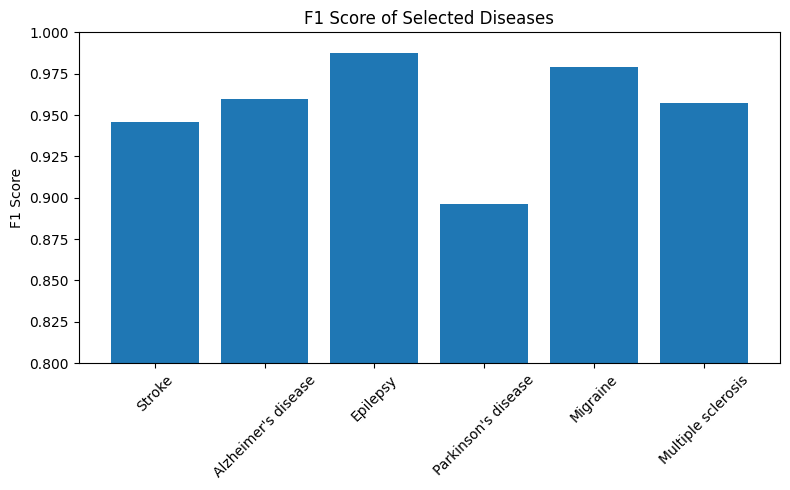

In [ ]:
# F1 score

selected_report = report_df.loc[selected_diseases]

plt.figure(figsize=(8,5))

plt.bar(
    selected_diseases,
    selected_report["f1-score"]
)

plt.title("F1 Score of Selected Diseases")

plt.ylabel("F1 Score")

plt.xticks(rotation=45)

plt.ylim(0.8,1.0)

plt.tight_layout()

plt.show()

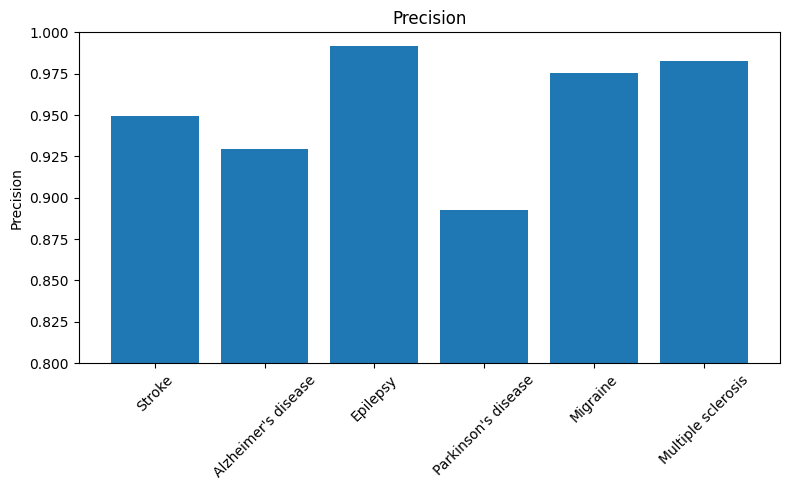

In [ ]:
# Precision Graph

plt.figure(figsize=(8,5))

plt.bar(
    selected_diseases,
    selected_report["precision"]
)

plt.title("Precision")

plt.ylabel("Precision")

plt.xticks(rotation=45)

plt.ylim(0.8,1.0)

plt.tight_layout()

plt.show()

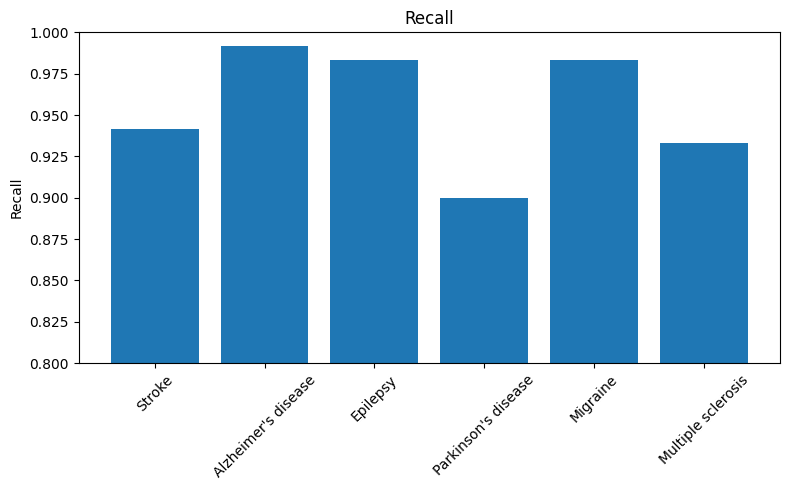

In [ ]:
# Recall Graph

plt.figure(figsize=(8,5))

plt.bar(
    selected_diseases,
    selected_report["recall"]
)

plt.title("Recall")

plt.ylabel("Recall")

plt.xticks(rotation=45)

plt.ylim(0.8,1.0)

plt.tight_layout()

plt.show()

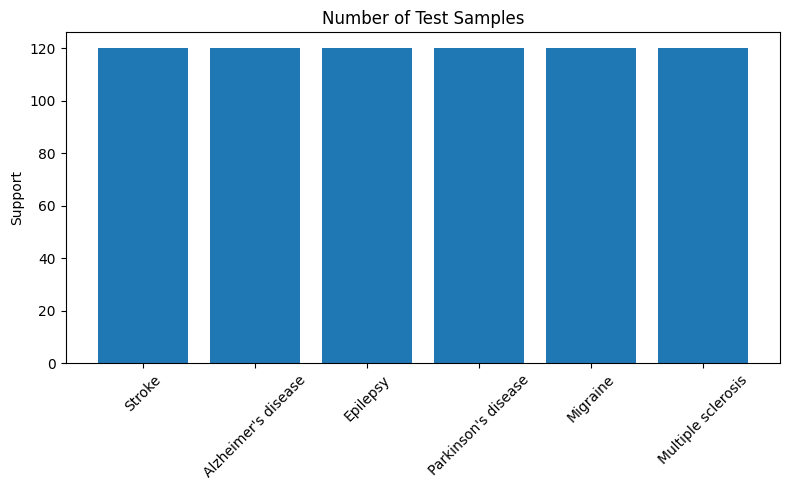

In [ ]:
# Support Graph


plt.figure(figsize=(8,5))

plt.bar(
    selected_diseases,
    selected_report["support"]
)

plt.title("Number of Test Samples")

plt.ylabel("Support")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

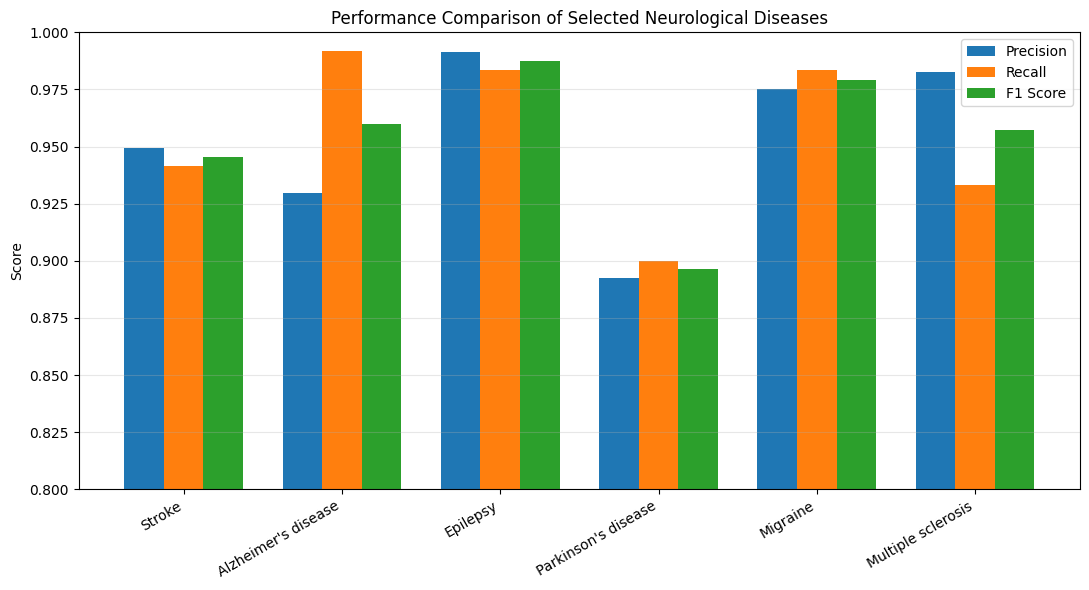

In [ ]:
selected_report = report_df.loc[selected_diseases]

x = np.arange(len(selected_diseases))
width = 0.25

plt.figure(figsize=(11,6))

plt.bar(
    x - width,
    selected_report["precision"],
    width,
    label="Precision"
)

plt.bar(
    x,
    selected_report["recall"],
    width,
    label="Recall"
)

plt.bar(
    x + width,
    selected_report["f1-score"],
    width,
    label="F1 Score"
)

plt.xticks(
    x,
    selected_diseases,
    rotation=30,
    ha="right"
)

plt.ylim(0.80,1.00)

plt.ylabel("Score")

plt.title("Performance Comparison of Selected Neurological Diseases")

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

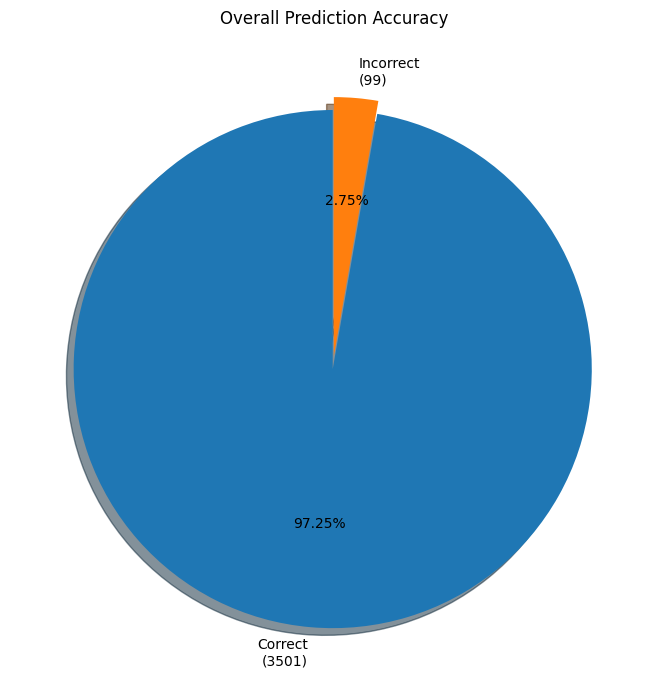

In [ ]:
correct = np.sum(y_true == y_pred)

wrong = len(y_true) - correct

plt.figure(figsize=(7,7))

plt.pie(
    [correct, wrong],
    labels=[
        f"Correct\n({correct})",
        f"Incorrect\n({wrong})"
    ],
    autopct="%1.2f%%",
    startangle=90,
    explode=(0.05,0),
    shadow=True
)

plt.title("Overall Prediction Accuracy")

plt.tight_layout()

plt.show()

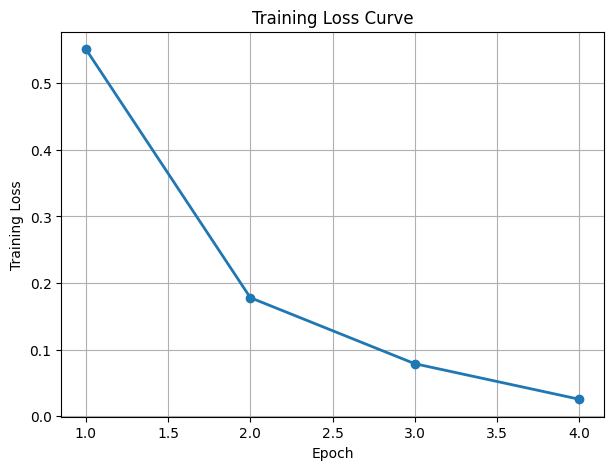

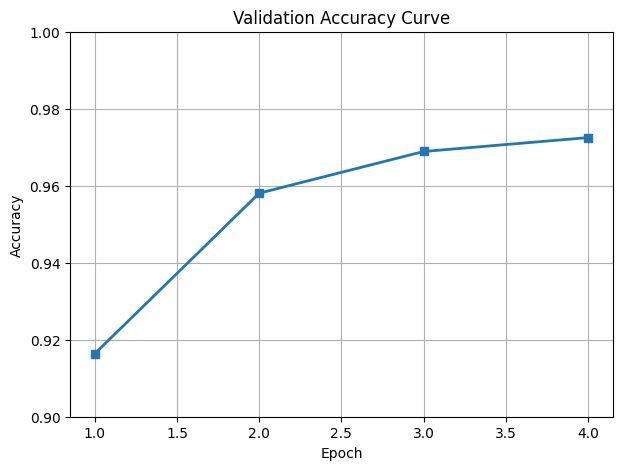

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = [1,2,3,4]

training_loss = [
    0.551338,
    0.177924,
    0.078686,
    0.025291
]

validation_accuracy = [
    0.916389,
    0.958056,
    0.968889,
    0.972500
]

plt.figure(figsize=(7,5))

plt.plot(
    epochs,
    training_loss,
    marker="o",
    linewidth=2
)

plt.title("Training Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.grid(True)

plt.show()

plt.figure(figsize=(7,5))

plt.plot(
    epochs,
    validation_accuracy,
    marker="s",
    linewidth=2
)

plt.title("Validation Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.ylim(0.90,1.00)

plt.grid(True)

plt.show()

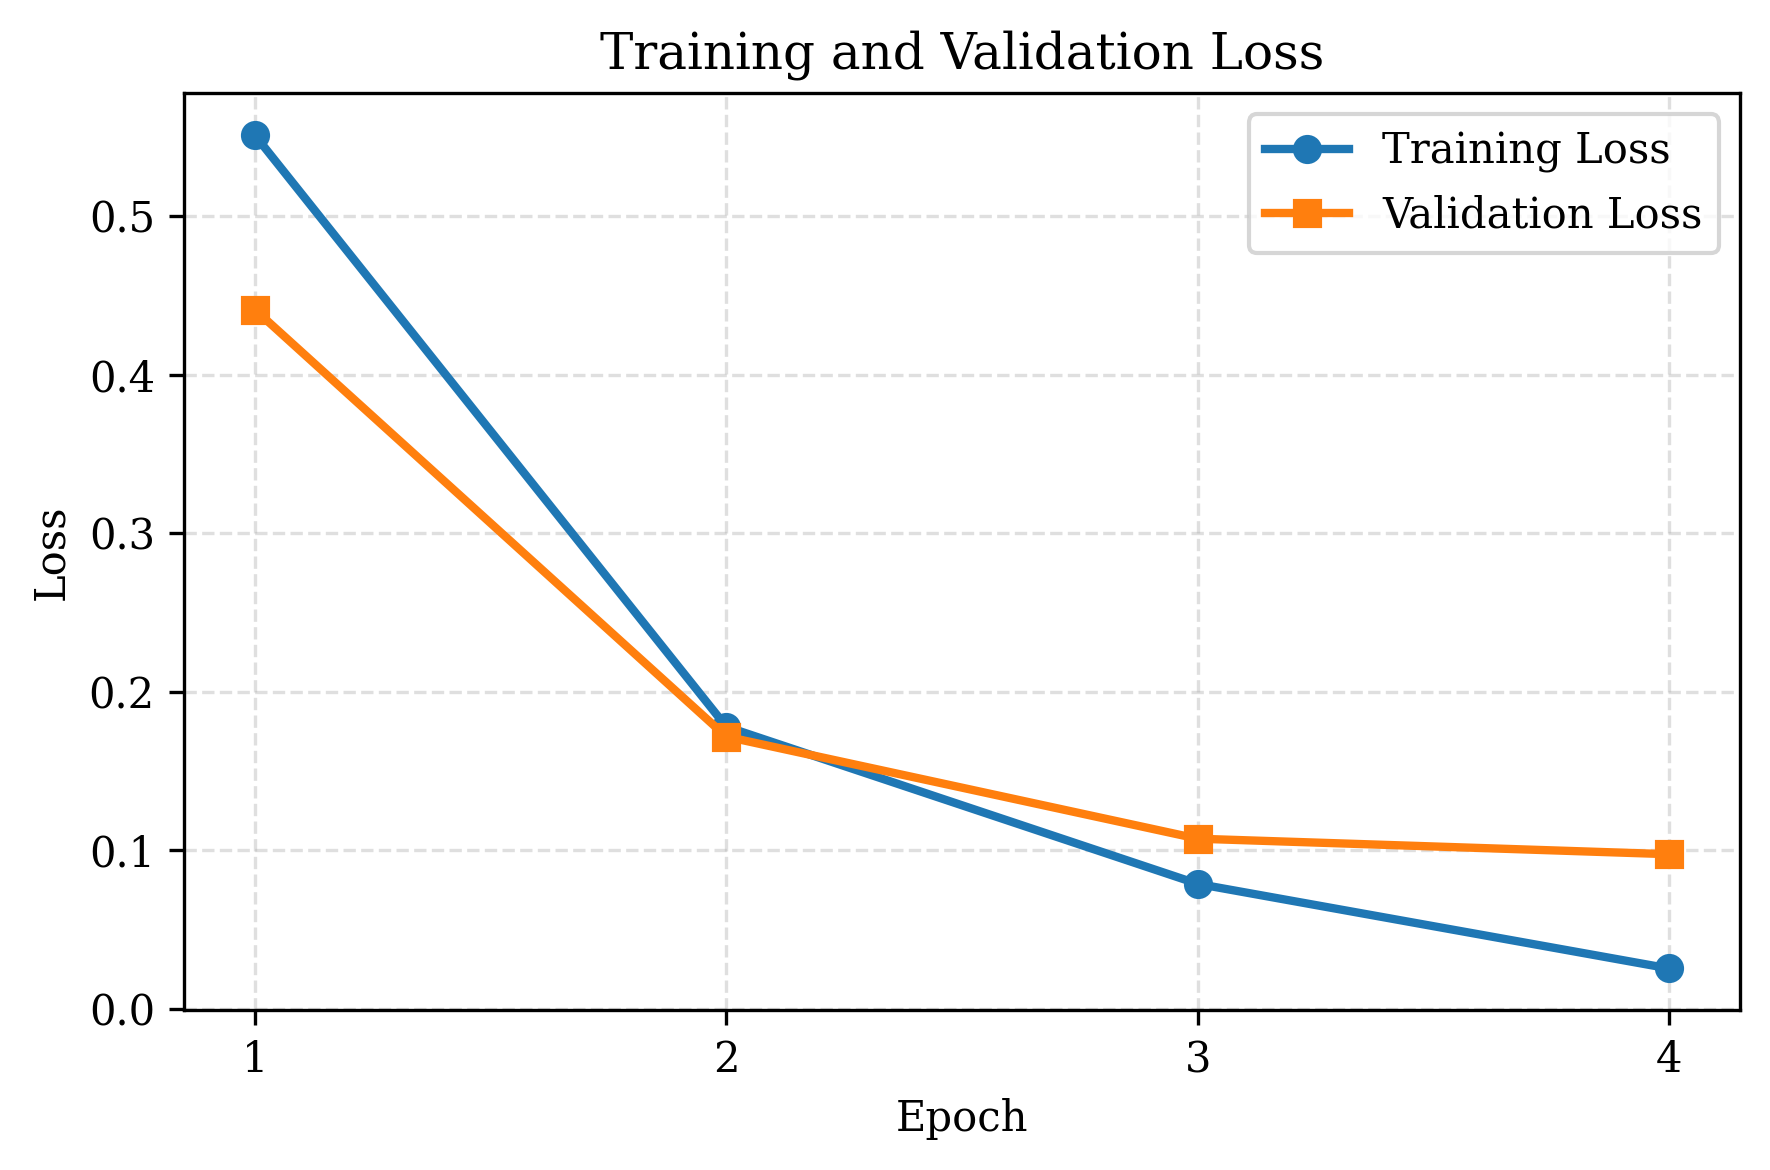

In [ ]:
import matplotlib.pyplot as plt

epochs = [1,2,3,4]

training_loss = [0.551338,0.177924,0.078686,0.025291]
validation_loss = [0.441242,0.171634,0.107226,0.097427]

plt.rcParams["font.family"] = "serif"

plt.figure(figsize=(6,4), dpi=300)

plt.plot(
    epochs,
    training_loss,
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.xticks(epochs)

plt.legend()

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig("training_validation_loss.png", dpi=300)

plt.show()